# 04 - Train/test, Machine Learning và metrics

Yêu cầu: chia train/test, huấn luyện Linear Regression, Ridge, Lasso và đánh giá bằng RMSE, MAE, R².


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")


def find_project_root() -> Path:
    current = Path.cwd().resolve()
    candidates = [current, *current.parents]
    for base in candidates:
        if (base / "data" / "wage_model.csv").exists():
            return base
        nested = base / "Machine Learning"
        if (nested / "data" / "wage_model.csv").exists():
            return nested
    raise FileNotFoundError("Không tìm thấy data/wage_model.csv. Hãy mở notebook trong folder Machine Learning.")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
RESULT_DIR = OUTPUT_DIR / "model_results"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

eda_df = pd.read_csv(DATA_DIR / "wage_eda.csv")
model_df = pd.read_csv(DATA_DIR / "wage_model.csv")

print("Project root found.")
print("EDA data:", eda_df.shape)
print("Model data:", model_df.shape)


Project root found.
EDA data: (3010, 30)
Model data: (3010, 38)


In [2]:
target = "lwage"

simple_features = ["educ"]
extended_features = [
    "educ", "exper", "expersq", "IQ", "KWW",
    "black", "south", "smsa", "fatheduc", "motheduc",
    "married_2", "married_3", "married_4", "married_5", "married_6",
]
full_features = [col for col in model_df.columns if col != target]

feature_groups = {
    "M1_simple": simple_features,
    "M2_extended": extended_features,
    "M3_full": full_features,
}

X_full = model_df[full_features]
y = model_df[target]

print("Target:", target)
print("M1 features:", len(simple_features))
print("M2 features:", len(extended_features))
print("M3 features:", len(full_features))


Target: lwage
M1 features: 1
M2 features: 15
M3 features: 37


## 4.1 Tạo nhóm vùng để chia train/test không random


In [3]:
region_cols = sorted([col for col in model_df.columns if col.startswith("reg66")])
region66 = pd.Series(1, index=model_df.index, name="region66")

for col in region_cols:
    region_code = int(col.replace("reg66", ""))
    region66.loc[model_df[col] == 1] = region_code

display(region66.value_counts().sort_index().rename("n_obs").to_frame())


,n_obs
region66,
1,140
2,484
3,589
4,193
5,627
6,289
7,331
8,85
9,272


## 4.2 Chia train/test theo vùng

Để tránh trộn các quan sát quá giống nhau giữa train và test, notebook dùng vùng 9 làm test set. Train gồm các vùng còn lại.


In [4]:
test_region = 9

train_mask = region66 != test_region
test_mask = region66 == test_region

X_train = X_full.loc[train_mask]
X_test = X_full.loc[test_mask]
y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)
print("Train regions:", sorted(region66.loc[train_mask].unique()))
print("Test region:", sorted(region66.loc[test_mask].unique()))


Train: (2738, 37) (2738,)
Test: (272, 37) (272,)
Train regions: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
Test region: [np.int64(9)]


## 4.3 Huấn luyện Linear Regression, Ridge và Lasso


In [5]:
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def regression_metrics(y_true, y_pred):
    return {
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
    }


alphas = np.logspace(-4, 4, 100)

models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RidgeCV(alphas=alphas, cv=5)),
    ]),
    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LassoCV(alphas=alphas, cv=5, max_iter=100000, random_state=42)),
    ]),
}

test_rows = []
predictions = {}

for name, estimator in models.items():
    estimator.fit(X_train, y_train)
    y_pred = estimator.predict(X_test)
    predictions[name] = y_pred
    row = {"model": name, **regression_metrics(y_test, y_pred)}
    fitted_model = estimator.named_steps["model"]
    row["selected_alpha"] = fitted_model.alpha_ if hasattr(fitted_model, "alpha_") else np.nan
    test_rows.append(row)

test_results = pd.DataFrame(test_rows).sort_values("rmse")
display(test_results.round(4))
test_results.to_csv(RESULT_DIR / "ml_test_metrics.csv", index=False)


,model,rmse,mae,r2,selected_alpha
2,Lasso,0.4053,0.3184,0.1535,0.0028
1,Ridge,0.4183,0.3334,0.0985,37.6494
0,Linear Regression,0.4220,0.3375,0.0822,NaN


## 4.4 Biểu đồ so sánh metrics


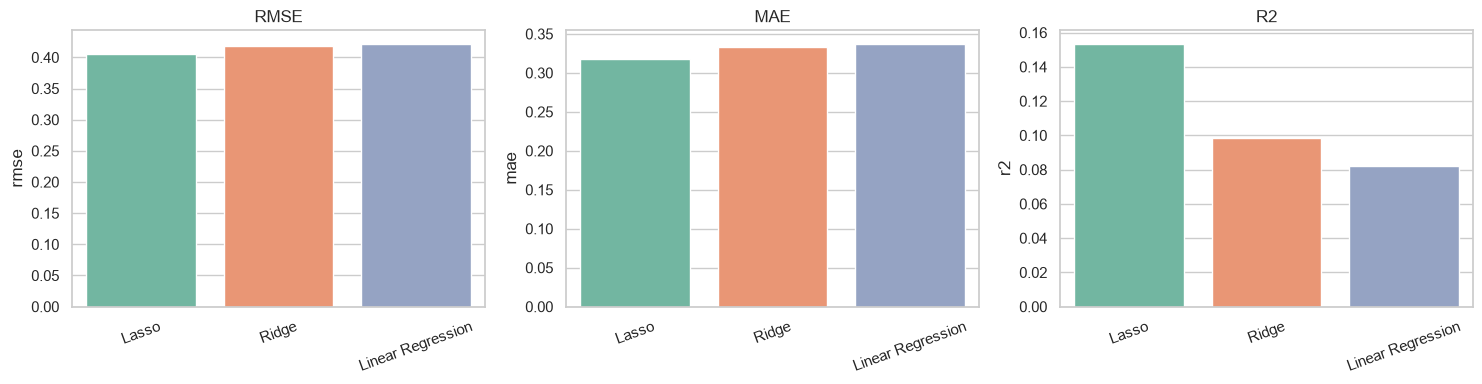

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, ["rmse", "mae", "r2"]):
    sns.barplot(data=test_results, x="model", y=metric, ax=ax, palette="Set2")
    ax.set_title(metric.upper())
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(FIG_DIR / "04_ml_test_metrics.png", dpi=200)
plt.show()


## 4.5 Actual vs Predicted và residual plot


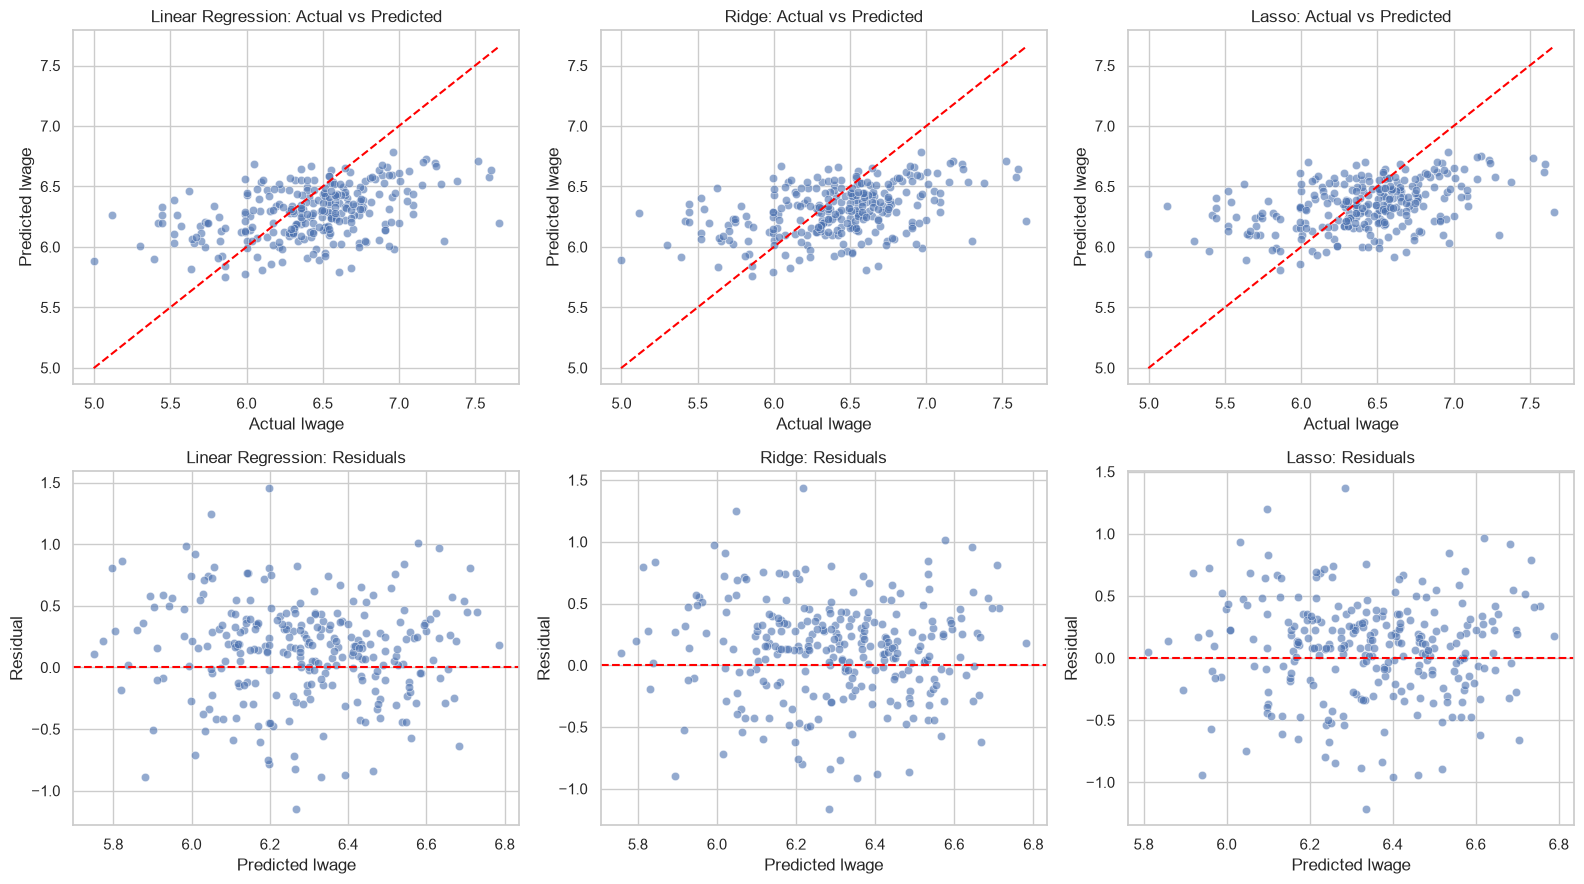

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for idx, (name, y_pred) in enumerate(predictions.items()):
    ax = axes[0, idx]
    sns.scatterplot(x=y_test, y=y_pred, ax=ax, alpha=0.6)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--")
    ax.set_title(f"{name}: Actual vs Predicted")
    ax.set_xlabel("Actual lwage")
    ax.set_ylabel("Predicted lwage")

    residuals = y_test - y_pred
    ax = axes[1, idx]
    sns.scatterplot(x=y_pred, y=residuals, ax=ax, alpha=0.6)
    ax.axhline(0, color="red", linestyle="--")
    ax.set_title(f"{name}: Residuals")
    ax.set_xlabel("Predicted lwage")
    ax.set_ylabel("Residual")

plt.tight_layout()
plt.savefig(FIG_DIR / "04_actual_predicted_residuals.png", dpi=200)
plt.show()


## Nhận xét ngắn

- RMSE/MAE càng thấp càng tốt; R² càng cao càng tốt.
- Chia theo vùng làm bài toán khó hơn random split, nhưng đánh giá nghiêm túc hơn vì test set là nhóm địa lý chưa xuất hiện trong train.
